### *O que vimos na aula passada...*

# **Integração numérica**

De modo geral vemos em cálculo que a integral de uma função é dada por:

$$\int_{a}^{b} f(x) dx = \lim_{x\to\infty} \sum_{n=1}^{\infty} f(x_n) \Delta x $$
Numéricamente o que fazemos é basicamente truncar a somatória acima em um N finito. A precisão obtida é dependente do valor de N adotado.

# **A regra dos trapézios**

Um exemplo simples da integração numérica usando a regra dos trapézios:

A área de um único trapézio entre os pontos $x_j$ and $x_{j+1}$ é dada por: $$ \frac{h}{2} (f(x_j) + f(x_{j+1})). $$

Somando isso sobre $n$ trapezóides em um dado intervalo [a,b] temos:

$$ h\left(\frac 1 2 f(x_0) + f(x_1) + f(x_2) + \cdots + f(x_{n-2}) + \frac 1 2 f(x_{n-1})\right) = h\sum_{j=0}^{n-1} f(x_j) - \frac h 2 \left(f(x_0) + f(x_{n-1})\right) = h\sum_{j=0}^{n-1} f(x_j) - \frac h 2 \left(f(a) + f(b))\right). $$


In [37]:
import numpy as np
import matplotlib.pyplot as plt

Primeiro definimos a função para qual desejamos obter o valor da integral:

In [38]:
def f(x):
    return (x-3)*(x-5)*(x-7)+85

Para podermos fazer o gráfico mostrando a função e os trapézios utilizados na integração, amostramos a função entre 0 e 10 utilizando 200 pontos:

In [39]:
x = np.linspace(0, 10, 200)
y = f(x)

defina a região onde se quer integrar e o número de trapézios a usar



In [40]:
a, b = 1, 8                     # define os limnites de integração

ndiv = 5                        # numero de pontos a serem utilizados
xint = np.linspace(a,b,ndiv)    # cria um vetor com ndiv elementos entre os limites de integração
yint = f(xint)                  # calcula o valor da função nos pontos do vetor acima

print(xint)
print(yint)

[1.   2.75 4.5  6.25 8.  ]
[ 37.        82.609375  86.875     81.953125 100.      ]


plotamos a curva e os trapézios usados para a integração



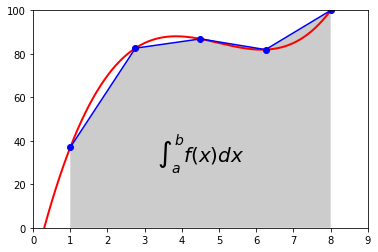

In [41]:
plt.plot(x, y, lw=2,color='r')
plt.axis([a-1, b+1, 0, max([f(a),f(b)])])
plt.fill_between(xint, 0, yint, facecolor='gray', alpha=0.4)
plt.text(0.5 * (a + b), 30,r"$\int_a^b f(x)dx$", horizontalalignment='center', fontsize=20);

plt.plot(xint,yint,'bo-')

### ***E na aula de hoje, veremos outro método de Integração Numérica...***

# **Método de Simpson**

O método dos trapézios aproxima a curva a ser integrada por uma série de segmentos de retas. Isto, na realidade, é de pouca precisão.

O método de Simpson se propõe a dar uma melhor precisão, uma vez que são usadas partes de parábolas para aproximar a curva a ser integrada. 

Neste caso "n" tem que ser **par**, pois são tomados dois subintervalos por vez. Isto significa dividir o intervalo de integração [x0,xn] em um número par de subintervalos e aplicar o método de Newton-Cotes a cada dois deles. 

O método de Simpson utiliza uma aproximação mais sofisticada para o intervalo a ser integrado.

Neste método se aproxima a função no intervalo [a,b] por um polinômio de segundo grau. Esse polinomio, conhecido como polinomio interpolador de Lagrange, tem o mesmo valor de $f(x)$ nos pontos a, b:

$$P(x)=f(a){\tfrac {(x-m)(x-b)}{(a-m)(a-b)}}+f(m){\tfrac {(x-a)(x-b)}{(m-a)(m-b)}}+f(b){\tfrac {(x-a)(x-m)}{(b-a)(b-m)}}.$$
Usando este polinomio calculado no ponto médio $m = (a + b) / 2$ e efetuando a sua integração obtem-se:

$$ \int _{a}^{b}f(x)\,dx\approx {\tfrac {b-a}{6}}\left[f(a)+4f\left({\tfrac {a+b}{2}}\right)+f(b)\right] $$
Essa expressão pode ser expandida para vários intervalos como foi feito para a regra dos trapézios:

$$ \int _{a}^{b}f(x)\,dx\approx {\tfrac {h}{3}}{\bigg [}f(a)+2\sum _{{j=1}}^{{n/2-1}}f(x_{{2j}})+4\sum _{{j=1}}^{{n/2}}f(x_{{2j-1}})+f(b){\bigg ]},$$


[1.   2.75 4.5 ] [37.       82.609375 86.875   ]
[4.5  6.25 8.  ] [ 86.875     81.953125 100.      ]


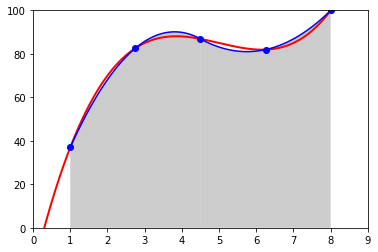

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

def f(x):
    return (x-3.)*(x-5.)*(x-7)+85.

x = np.linspace(0, 10, 400)
y = f(x)

a, b = 1., 8.                     # define os limites de integração

ndiv = 4                        # numero de divisões a serem utilizadas DEVE SER PAR!
xint = np.linspace(a,b,ndiv+1)    # cria um vetor com ndiv elementos entre os limites de integração
yint = f(xint)                  # calcula o valor da função nos pontos do vetor acima


plt.plot(x, y, lw=2,color='r')
plt.axis([a-1, b+1, 0, max([f(a),f(b)])])
plt.plot(xint,yint,'bo')


for i in range(0,ndiv,2):
    xfit = np.array([xint[i],(xint[i]+xint[i+2])/2,xint[i+2]])
    yfit = f(xfit)
    print (xfit,yfit)
    # calculate polynomial
    #z = np.polyfit(xfit, yfit, 1)
    
    # using Lagrange interpolator    
    z = lagrange(xfit, yfit)
    #print("Fit coeficients", z)
    
    fit = np.poly1d(z)
    
    xnew = np.linspace(xfit[0], xfit[2], 50)
    ynew = fit(xnew)
    
    plt.plot(xnew,ynew,color='b')
    plt.fill_between(xnew, 0, ynew, facecolor='gray', alpha=0.4)

## **As fórmulas dos Métodos dos Trapézios e de Simpson**

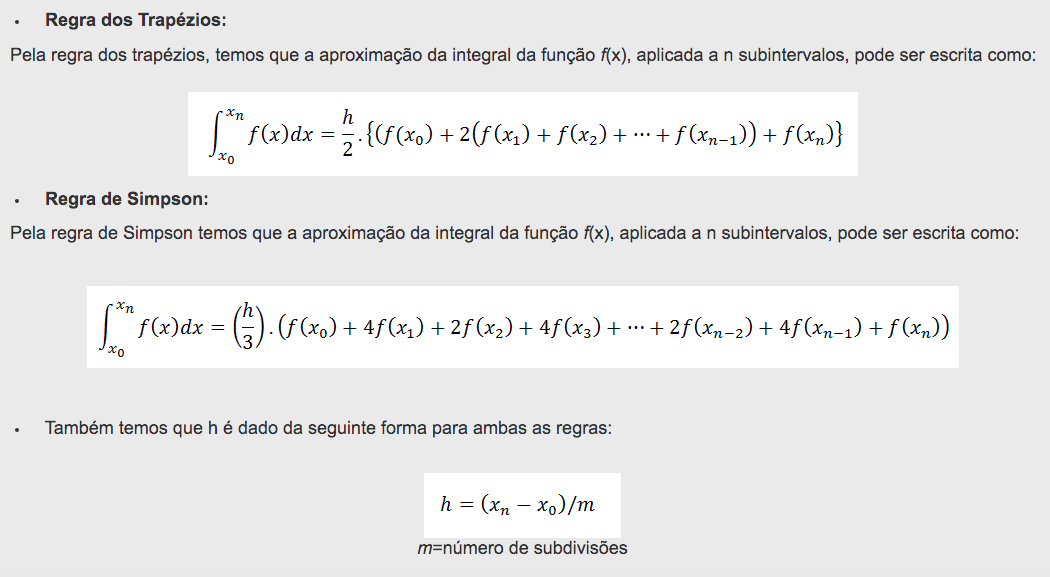

**Vamos resolver o exercício 1 completo, cobrando os métodos dos Trapézios e de Simpson:**


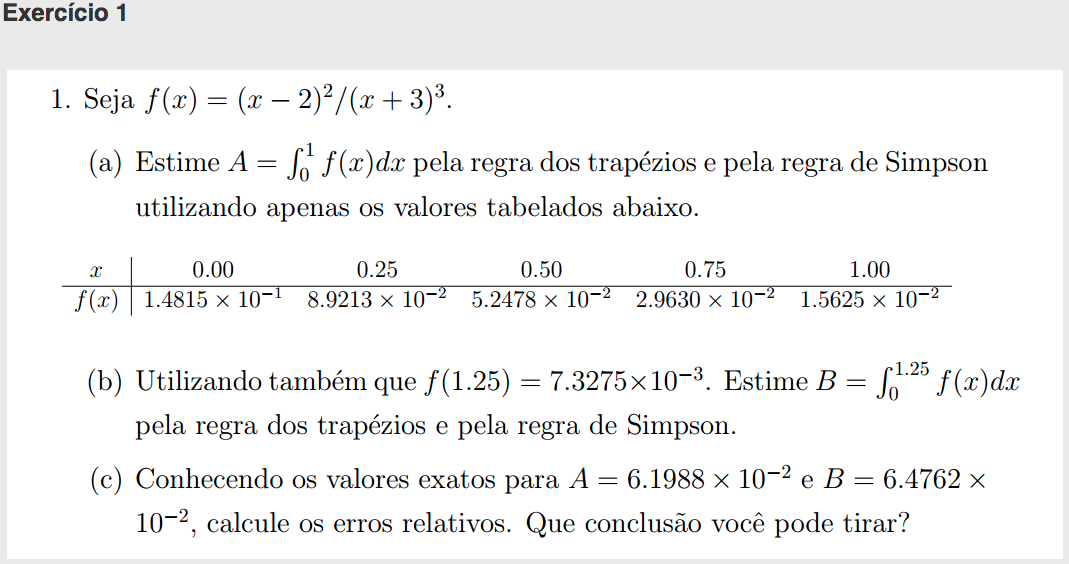

### *Sabendo que, as integrais exatas de A e B (em Python):*

In [44]:
# Vamos importar a biblioteca Python de matemática simbólica 'Sympy' para calcular a integral
#Resposta exata da integral A
from sympy import Symbol, integrate
x = Symbol('x')
integrate(((x-2)**2)/((x+3)**3),(x,0.0,1.0))

In [ ]:
#Resposta exata da integral B
from sympy import Symbol, integrate
x = Symbol('x')
integrate(((x-2)**2)/((x+3)**3),(x,0.0,1.25))

0.0647619038030101

# Resposta (a)

In [45]:
x=[0,0.25,0.5,0.75,1]
y=[1.4815*10**(-1),8.9213*10**(-2),5.2478*10**(-2),2.9630*10**(-2),1.5625*10**(-2)]

In [46]:
def Trapezio(listax,listay):
  import math
  tam=len(listax)
  div=tam-1
  h=((listax[div])-listax[0])/div
  somfunc=0 #somatório das funções de x1 a xn-1
  for i in range(1,div):
    somfunc=somfunc + listay[i]
  #print(somfunc)
  res = (h/2)*((listay[0])+(listay[div])+(2*(somfunc))) #regra do trapézio  
  return res 
print(Trapezio(x,y))  

0.063302125


In [47]:
# A função trapz(): integra ao longo do eixo determinado usando a regra trapezoidal composta
from scipy.integrate import trapz
trapz(y,x)

In [48]:
def Simpson(listax,listay):
  import math
  tam = len(listax)
  div=tam-1
  h=((listax[div])-listax[0])/div
  somafunc=0
  for i in range(1,div):
    if (i%2)!= 0:
      somafunc=somafunc+(4*(listay[i]))
    else:
      somafunc=somafunc+(2*(listay[i]))
  res=(h/3)*(somafunc+(listay[0])+(listay[div]))
  return res 
print(Simpson(x,y))        

0.062008583333333325


In [49]:
# A função simps(): integra ao longo do eixo determinado usando a regra de Simpson
from scipy.integrate import simps
simps(y,x)

# Resposta (b)

In [50]:
xb=[0,0.25,0.5,0.75,1,1.25]  #xb=[x0,x1,x2,x3,x4,x5] => n = 5 é impar!!
yb=[1.4815*10**(-1),8.9213*10**(-2),5.2478*10**(-2),2.9630*10**(-2),1.5625*10**(-2),7.3275*10**(-3)]

In [51]:
#Trapézio
Trapezio(xb,yb)

In [52]:
#A função trapz(): integra ao longo do eixo determinado usando a regra trapezoidal composta
from scipy.integrate import trapz
trapz(yb,xb)

In [53]:
#Simpson
Simpson(xb,yb)

In [54]:
#Simpson
# A função simps(): integra ao longo do eixo determinado usando a regra de Simpson
from scipy.integrate import simps
simps(yb,xb)

### Para xb=[0,0.25,0.5,0.75,1,1.25] => xb=[x0,x1,x2,x3,x4,x5] => n = 5 é impar!! Porém, para o método de Simpson o "n" tem que ser PAR!!

### ***Vamos encontrar na letra (c) os erros relativos (percentual) com relação aos métodos nas letras (a) e (b).***

# Resposta (c)

In [55]:
#Erro relativo (percentual) 
def ErroRelperc(xreal,xcalculado):
  return (abs(xreal - xcalculado)/xreal)*100

#dados: valores exatos das integrais
A = 6.1988e-2   #Para x= x=[0,0.25,0.5,0.75,1]
B = 6.4762e-2   #Para xb=[0,0.25,0.5,0.75,1,1.25]

print("Em A, por Trapézios..." + str(ErroRelperc(A,Trapezio(x,y))) + "%")
print("Em A, por Simpson....." + str(ErroRelperc(A,Simpson(x,y))) + "%")
print("Em B, por Trapézios..." + str(ErroRelperc(B,Trapezio(xb,yb))) + "%")
print("Em B, por Simpson....." + str(ErroRelperc(B,Simpson(xb,yb))) + "%")
print("Em B, por Python......" + str(ErroRelperc(B,simps(yb,xb))) + "%")

Em A, por Trapézios...2.1199667677615013%
Em A, por Simpson.....0.03320535157340752%
Em B, por Trapézios...2.175948086841058%
Em B, por Simpson.....1.2981506644843313%
Em B, por Python......0.5469224493787403%


***O resultado do exercício 1(b) do cálculo do erro relativo (percentual) com "n" ímpar, o erro relativo (percentual) aplicando o método de Simpson foi inferior ao erro relativo (percentual) aplicando o método dos Trapézios, mesmo que para "n" ímpar.***

**O resultado do exercício 1(a) do cálculo do erro relativo (percentual) aplicando o método dos Trapézios foi 63 vezes superior ao erro relativo (percentual) aplicando o método de Simpson para "n" par. O que confirma a melhor precisão no resultado da integral aplicando o método de Simpson.**

**Logo, o método de Simpson é melhor aplicado para um número PAR de subintervalos.**

# **Erros referentes a cada Método:**




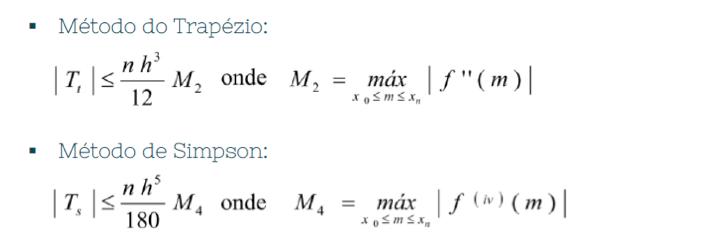

**A) Regra do trapézio:**

**Resolução através do Python:**



### Para calcular o erro no método dos trapézios precisamos encontrar a 2a derivada de f(x): f''(x)

In [56]:
# Vamos importar a biblioteca Python de matemática simbólica 'Sympy' para calcular a derivada
from sympy import *
init_printing()
var('x,y')

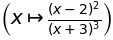

In [58]:
#Função da questão 1: f(x) = (x-2)**2/(x+3)**3
f = Lambda(x, ((x-2)**2)/((x+3)**3)) 
f

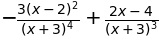

In [59]:
#Derivada de f(x): f'(x)
diff(f(x), x)

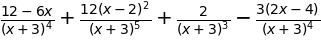

In [60]:
#A 2a derivada de f(x): f''(x)
diff(diff(f(x), x), x)

In [62]:
#Para avaliar a 2a derivada no ponto x = 0: f''(0)
M2a = diff(diff(f(x), x), x).subs(x,0) 
print(M2a)  ## 46/81 = 0.5679012345679012  =====> Valor máximo para M2a, para calcularmos o erro no método dos trapézios

46/81


In [63]:
#Para avaliar a 2a derivada no ponto x = 1: f''(1)
M2b = diff(diff(f(x), x), x).subs(x,1)  
print(M2b)   # 23/256 = 0.08984375      ======>  M2b < M2a   

23/256


In [64]:
#erro letra (A) - usando erro do método dos Trapézio

listax=[0,0.25,0.5,0.75,1]
listay=[1.4815*10**(-1),8.9213*10**(-2),5.2478*10**(-2),2.9630*10**(-2),1.5625*10**(-2)]

def ErroTrapezio(listax,listay):
  tam=len(listax)
  div=tam-1
  h=((listax[div])-listax[0])/div
  n= div
  Max2 = M2a                     ## Máximo valor da 2a derivada para x = 0
  erro= ((n*h**(3))*Max2)/12
  return erro
print(ErroTrapezio(listax,listay))  


0.00295781893004115


### Resultado do erro aplicando o método dos Trapézios (exercício 1(a)): **0.00295781893004115**

**B) Regra de Simpson:**


### Para calcular o erro no método de Simpson precisamos encontrar a 4a derivada de f(x): f_iv(x)

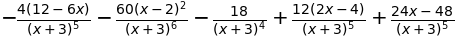

In [65]:
#A 3a derivada de f(x): f'''(x)
diff(diff(diff(f(x), x), x), x)

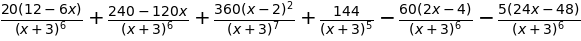

In [66]:
#A 4a derivada de f(x): f_iv(x)
diff(diff(diff(diff(f(x), x), x), x), x)

In [67]:
#Para avaliar a 4a derivada no ponto x = 0: f_iv(0)
M4a = diff(diff(diff(diff(f(x), x), x), x), x).subs(x,0) 
print(M4a)  ## 208/81 = 2.56790123457   =====> Valor máximo para M4a, para calcularmos o erro no método dos trapézios

208/81


In [68]:
#Para avaliar a 4a derivada no ponto x = 1: f_iv(1)
M4b = diff(diff(diff(diff(f(x), x), x), x), x).subs(x,1)  
print(M4b)   ## 573/2048 = 0.27978515625    ======>  M4b < M4a  

573/2048


In [69]:
#erro letra (A) - usando erro de Simpson

listax=[0,0.25,0.5,0.75,1]
listay=[1.4815*10**(-1),8.9213*10**(-2),5.2478*10**(-2),2.9630*10**(-2),1.5625*10**(-2)]

def ErroSimpson(listax,listay):
  tam=len(listax)
  div=tam-1
  h=((listax[div])-listax[0])/div
  n= div
  Max4 = M4a                      ## Máximo valor da 4a derivada para x = 0
  erro= ((n*h**(5))*Max4)/180
  return erro
print(ErroSimpson(listax,listay))  

5.57270233196159e-5


### Resultado do erro aplicando o método de Simpson (exercício 1(a)): **5.57270233196159e-5**

### **OBS:**
### Diantes dos resultados dos erros cálculados para os métodos dos Trapézios e de Simpson, podemos concluir que: 

1.   **O método dos trapézios tem pouca precisão porque aproxima a curva a ser integrada por uma série de segmentos de retas.**
2.   **Enquanto que, o método de Simpson se propõe a dar uma melhor precisão, uma vez que são usadas partes de parábolas para aproximar a curva a ser integrada.**


## **EXERCÍCIOS:**

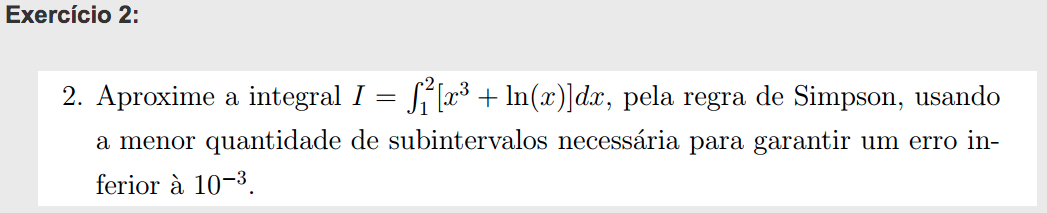

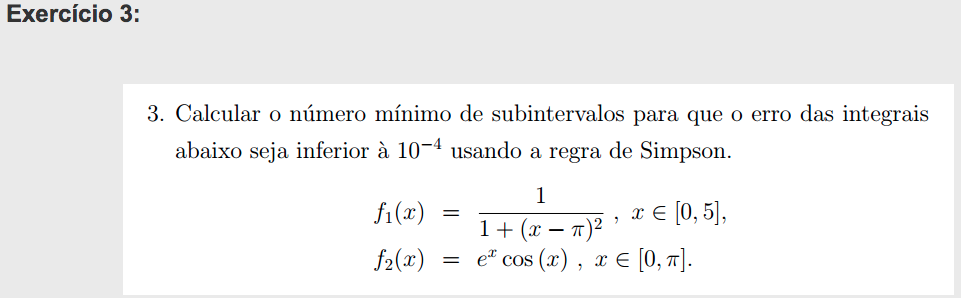

## **Exercício 4:**

 Considere a integral:

$$
 \int_{1}^{2} f(x)\, dx 
$$


*   Onde: *f(x) = 1/(1+x)ˆ2*
*   (a) Determine o menor valor de "n" que garanta, no caso do método dos trapézios, um erro inferior a 1e-6.
*   (b) Determine o menor valor de "n" que garanta, no caso do método de Simpson, um erro inferior a 1e-6.
